In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import loadmat
from scipy.fft import rfft, rfftfreq

In [2]:
FS = 12000
file_path = "../data/raw/CWRU/NORMAL_0.mat"
data = loadmat(file_path)

print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'X097_DE_time', 'X097_FE_time', 'X097RPM'])


In [3]:
de_keys = [
    key for key in data.keys()
    if "DE_time" in key
]

print("DE variables:", de_keys)

DE variables: ['X097_DE_time']


In [4]:
de_key = de_keys[0]

vibration = data[de_key].squeeze()

print("DE variable:", de_key)
print("Number of samples:", len(vibration))

DE variable: X097_DE_time
Number of samples: 243938


In [5]:
signal = vibration[:FS]
print("Samples in FFT window:", len(signal))

Samples in FFT window: 12000


In [6]:
time = np.arange(FS) / FS

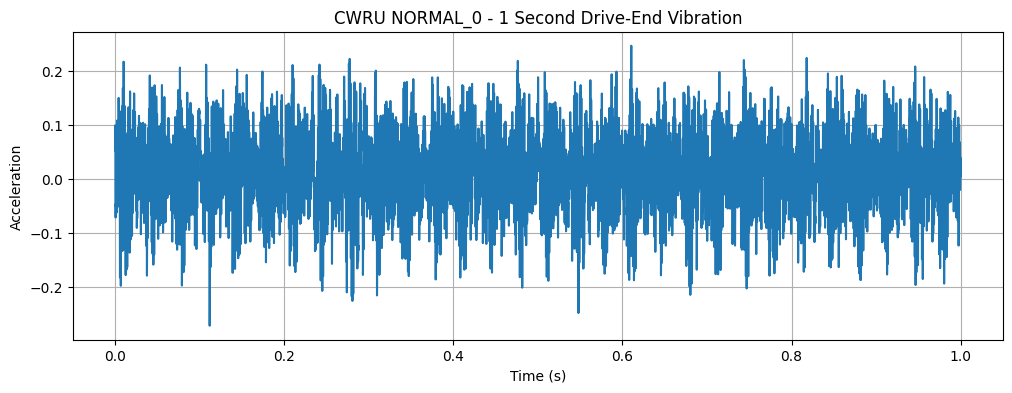

In [7]:
plt.figure(figsize=(12, 4))

plt.plot(time, signal)

plt.xlabel("Time (s)")
plt.ylabel("Acceleration")

plt.title("CWRU NORMAL_0 - 1 Second Drive-End Vibration")

plt.grid()

plt.show()

In [8]:
N = len(signal)

fft_values = rfft(signal)

In [9]:
frequencies = rfftfreq(
    N,
    d=1 / FS
)

In [10]:
magnitude = np.abs(fft_values)

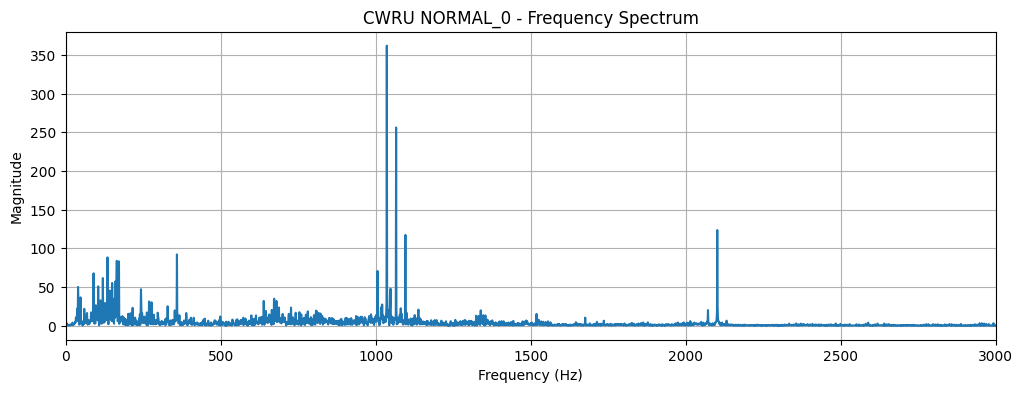

In [11]:
plt.figure(figsize=(12, 4))

plt.plot(
    frequencies,
    magnitude
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")

plt.title(
    "CWRU NORMAL_0 - Frequency Spectrum"
)

plt.xlim(0, 3000)

plt.grid()

plt.show()

In [12]:
frequency_resolution = FS / N

print(
    "Frequency resolution:",
    frequency_resolution,
    "Hz"
)

Frequency resolution: 1.0 Hz


In [13]:
rpm_keys = [
    key for key in data.keys()
    if "RPM" in key
]

print("RPM variables:", rpm_keys)
rpm = float(
    np.asarray(
        data[rpm_keys[0]]
    ).squeeze()
)

print("RPM:", rpm)

RPM variables: ['X097RPM']
RPM: 1796.0


In [14]:
running_frequency = rpm / 60

print(
    "Running frequency:",
    running_frequency,
    "Hz"
)

Running frequency: 29.933333333333334 Hz


In [15]:
order_1x = running_frequency
order_2x = 2 * running_frequency
order_3x = 3 * running_frequency

print("1x:", order_1x, "Hz")
print("2x:", order_2x, "Hz")
print("3x:", order_3x, "Hz")

1x: 29.933333333333334 Hz
2x: 59.86666666666667 Hz
3x: 89.8 Hz


In [23]:
BPFI_MULT = 5.4152
BPFO_MULT = 3.5848
FTF_MULT = 0.39828
BSF_MULT = 4.7135

running_frequency = rpm / 60

bpfi = BPFI_MULT * running_frequency
bpfo = BPFO_MULT * running_frequency
ftf = FTF_MULT * running_frequency
bsf = BSF_MULT * running_frequency

print("Running Frequency:", running_frequency)
print("BPFI:", bpfi)
print("BPFO:", bpfo)
print("FTF:", ftf)
print("BSF:", bsf)

Running Frequency: 29.933333333333334
BPFI: 162.09498666666664
BPFO: 107.30501333333333
FTF: 11.921848
BSF: 141.09076666666667


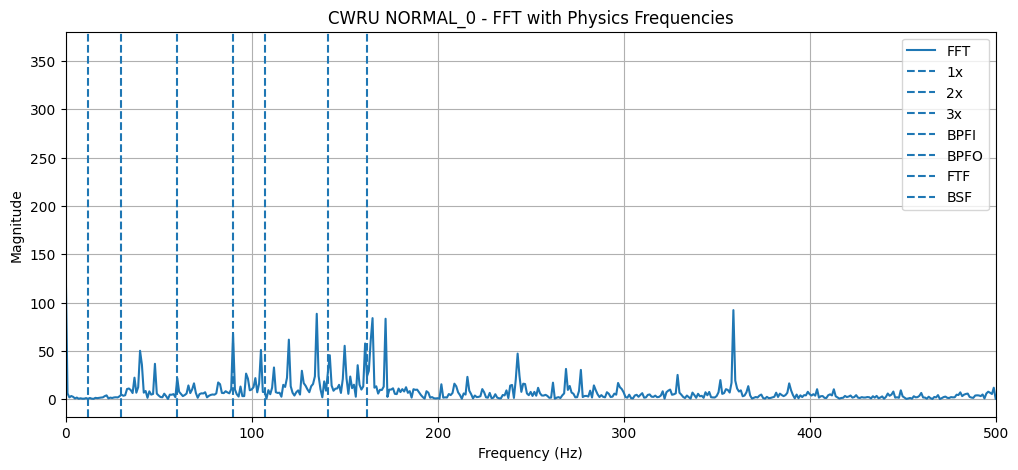

In [28]:
plt.figure(figsize=(12, 5))

plt.plot(
    frequencies,
    magnitude,
    label="FFT"
)

# Running-speed components
plt.axvline(
    order_1x,
    linestyle="--",
    label="1x"
)

plt.axvline(
    order_2x,
    linestyle="--",
    label="2x"
)

plt.axvline(
    order_3x,
    linestyle="--",
    label="3x"
)

# Bearing characteristic frequencies
plt.axvline(
    bpfi,
    linestyle="--",
    label="BPFI"
)

plt.axvline(
    bpfo,
    linestyle="--",
    label="BPFO"
)

plt.axvline(
    ftf,
    linestyle="--",
    label="FTF"
)

plt.axvline(
    bsf,
    linestyle="--",
    label="BSF"
)

plt.xlim(0, 500)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")

plt.title(
    "CWRU NORMAL_0 - FFT with Physics Frequencies"
)

plt.legend()
plt.grid()

plt.show()

In [18]:
files_to_analyze = {
    "Healthy": "../data/raw/CWRU/NORMAL_0.mat",
    "Inner Race": "../data/raw/CWRU/IR007_0.mat",
    "Ball": "../data/raw/CWRU/B007_0.mat",
    "Outer Race": "../data/raw/CWRU/OR007@6_0.mat"
}

In [29]:
def calculate_fft(signal, fs):

    N = len(signal)

    fft_values = rfft(signal)

    frequencies = rfftfreq(
        N,
        d=1 / fs
    )

    magnitude = np.abs(fft_values)

    return frequencies, magnitude

In [30]:
frequencies, magnitude = calculate_fft(
    signal,
    FS
)

In [31]:
plt.savefig(
    "../data/processed/CWRU/figures/NORMAL_0_fft.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>